# Task 7: Ensemble Learning — Random Forest vs XGBoost

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

### 1. Load and prep data

In [23]:
churn_data = pd.read_csv("../data/telco_churn.csv")
churn_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [24]:
churn_data['TotalCharges'] = pd.to_numeric(churn_data['TotalCharges'], errors='coerce')
churn_data = churn_data.dropna(subset=['TotalCharges'])
churn_data = churn_data.drop(columns=['customerID'])
churn_data['Churn'] = churn_data['Churn'].map({'Yes': 1, 'No': 0})

churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 2. Feature Engineering

In [25]:
churn_data['Avg_Monthly_Spend'] = churn_data['TotalCharges'] / churn_data['tenure'].replace(0, 1)

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
churn_data['Num_Services'] = churn_data[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

churn_data[['Avg_Monthly_Spend', 'Num_Services']].head()

,Avg_Monthly_Spend,Num_Services
0,29.850000,1
1,55.573529,2
2,54.075000,2
3,40.905556,3
4,75.825000,0


### 3. Define Features, Target, and Column Groups

In [26]:
X = churn_data.drop(columns=['Churn'])
y = churn_data['Churn']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Avg_Monthly_Spend', 'Num_Services']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train shape: (5625, 21) | Test shape: (1407, 21)


### 4. Build Preprocessing and Model Pipelines

In [27]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# 1. Logistic Regression (single-model baseline)
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10,
                                          random_state=42, n_jobs=-1))
])

# 3. XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit all three
lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


### 5. Evaluate and Compare

In [28]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = [
    evaluate(lr_pipe, 'Logistic Regression'),
    evaluate(rf_pipe, 'Random Forest'),
    evaluate(xgb_pipe, 'XGBoost')
]
results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Accuracy      F1  ROC-AUC
0  Logistic Regression    0.8031  0.6049   0.8361
1        Random Forest    0.7861  0.5474   0.8344
2              XGBoost    0.7839  0.5556   0.8267


In [29]:
for name, pipe in [('Logistic Regression', lr_pipe), ('Random Forest', rf_pipe), ('XGBoost', xgb_pipe)]:
    print(f"\n{name}")
    print(classification_report(y_test, pipe.predict(X_test), target_names=['No Churn', 'Churn']))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


XGBoost
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.86      1033
       Churn       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      

## Model Comparison Table
| Model | Accuracy | F1 Score | ROC-AUC |
|-------|----------|----------|---------|
| Logistic Regression | 0.8031 | 0.6049 | 0.8361 |
| Random Forest | 0.7861 | 0.5474 | 0.8344 |
| XGBoost | 0.7839 | 0.5556 | 0.8267 |

### 6. Feature Importance Comparison

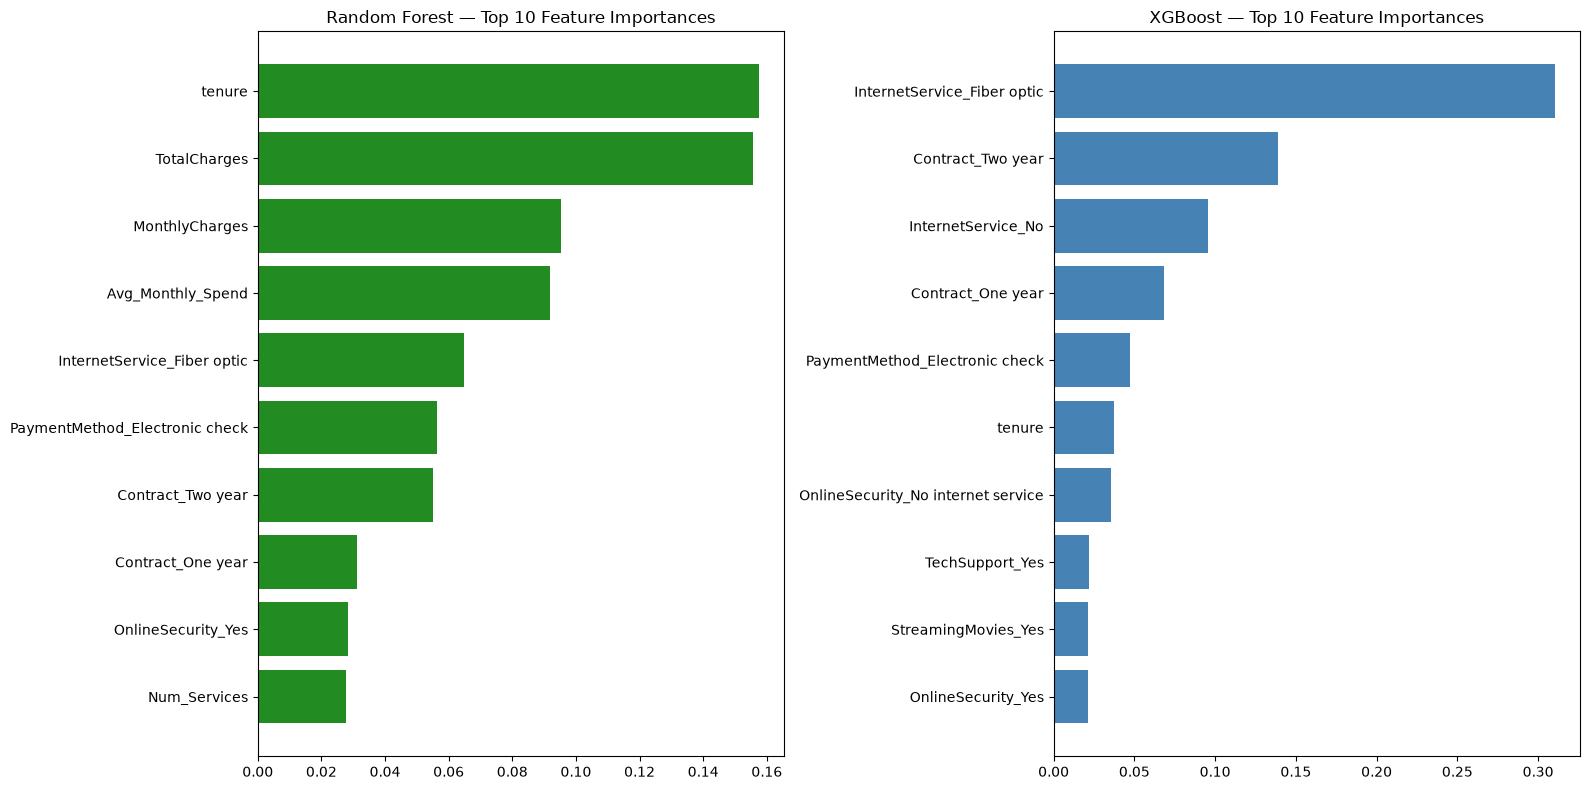

Random Forest Top 3:
       Feature  Importance
        tenure    0.157574
  TotalCharges    0.155659
MonthlyCharges    0.095460

XGBoost Top 3:
                    Feature  Importance
InternetService_Fiber optic    0.310417
          Contract_Two year    0.138727
         InternetService_No    0.095351


In [30]:
ohe = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, cat_feature_names])

rf_importances = rf_pipe.named_steps['classifier'].feature_importances_
xgb_importances = xgb_pipe.named_steps['classifier'].feature_importances_

rf_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': rf_importances})
xgb_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': xgb_importances})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

rf_top = rf_imp_df.sort_values('Importance', ascending=False).head(10)
axes[0].barh(rf_top['Feature'], rf_top['Importance'], color='forestgreen')
axes[0].set_title('Random Forest — Top 10 Feature Importances')
axes[0].invert_yaxis()

xgb_top = xgb_imp_df.sort_values('Importance', ascending=False).head(10)
axes[1].barh(xgb_top['Feature'], xgb_top['Importance'], color='steelblue')
axes[1].set_title('XGBoost — Top 10 Feature Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Random Forest Top 3:")
print(rf_top.head(3)[['Feature', 'Importance']].to_string(index=False))
print("\nXGBoost Top 3:")
print(xgb_top.head(3)[['Feature', 'Importance']].to_string(index=False))

### 8. Save Best Model for Deployment

In [31]:
best_pipe = lr_pipe   # or rf_pipe / xgb_pipe

joblib.dump(best_pipe, '../models/churn_pipeline.pkl')
print("Best model saved to models/churn_pipeline.pkl")

Best model saved to models/churn_pipeline.pkl


### Conclusion
- Random Forest builds many decision trees independently and in parallel, each trained on a 
random subset of data and features, then averages their predictions (bagging) — this reduces 
variance and overfitting. 

- XGBoost builds trees sequentially, where each new tree specifically 
tries to correct the errors made by the previous trees (boosting), which often gives higher 
accuracy but makes it more prone to overfitting if not tuned carefully. 
#### 
In this dataset, both 
approaches performed close to Logistic Regression, suggesting churn is driven mostly by fairly 
linear patterns rather than complex feature interactions that ensembles are best at capturing.
